In [76]:
# Implement a large matrix multiplication using both naive (custom function) 
# and optimized (numpy function) methods and compare their runtimes.

import timeit
import numpy as np
import random

# creating & randomizing matricies
a = np.zeros((3, 3))
a2 = np.zeros((3, 3))
b = np.zeros((6, 6))
b2 = np.zeros((6, 6))
c = np.zeros((12, 12))
c2 = np.zeros((12, 12))
d = np.zeros((24, 24))
d2 = np.zeros((24, 24))
e = np.zeros((48, 48))
e2 = np.zeros((48, 48))
f = np.zeros((96, 96))
f2 = np.zeros((96, 96))
g = np.zeros((192, 192))
g2 = np.zeros((192, 192))
h = np.zeros((384, 384))
h2 = np.zeros((384, 384))

# Replace zero values with random ints between -5 and 5
def create_num(a):    
    for i in range(len(a[0])):
        for j in range(len(a[0])):
            a[i][j] = random.randint(-5, 5)
            j += 1
        i += 1
    return a

# calls the function in a for loop
lst = [a, a2, b, b2, c, c2, d, d2, e, e2, f, f2, g, g2, h, h2]
for i in lst:
    create_num(i)
print("Finished randomizing matricies!")



Finished randomizing matricies!


In [77]:
# naive function, time it.

# from lecture
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
        return C

# implementing matrix mult from lecture
def main_naive():
    time_it_takes = []
    for i in range(0, len(lst), 2):
        n = lst[i]
        m = lst[i+1]
        
        start = time.time()
        naive_matrix_multiplication(n, m)
        end = time.time()
        time_it_takes.append((f"{end-start:.4f}"))
    
    print("Finished naive multiplication")
    print(len(time_it_takes))
    return time_it_takes
        
time_it_takes = main_naive()

Finished naive multiplication
8


In [78]:
# optimized, time it.
def main_npy():
    time_it_takes2 = []
    for i in range(0, len(lst), 2):
        n = lst[i]
        m = lst[i+1]
        start = time.time()
        np.matmul(n, m)
        end = time.time()
        time_it_takes2.append((f"{end-start:.4f}"))
    
    print("Finished numpy multiplication")
    return time_it_takes2

time_it_takes2 = main_npy()

print(time_it_takes)
print(time_it_takes2)

Finished numpy multiplication
['0.0002', '0.0001', '0.0002', '0.0008', '0.0033', '0.0100', '0.0457', '0.1527']
['0.0003', '0.0000', '0.0000', '0.0000', '0.0002', '0.0005', '0.0008', '0.0043']


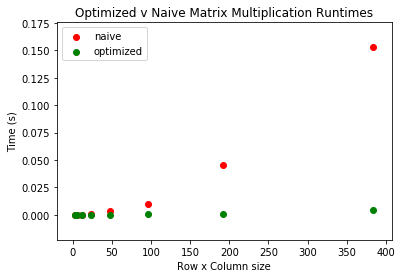

In [79]:
# Plotting it
import matplotlib.pyplot as plt

x = (3, 6, 12, 24, 48, 96, 192, 384)
y1 = time_it_takes
y2 = time_it_takes2
y1 = [float(v) for v in y1]
y2 = [float(v) for v in y2]
plt.scatter(x, y1, color ='red', label = "naive")
plt.scatter(x, y2, color = 'green', label = 'optimized')
plt.xlabel("Row x Column size")
plt.ylabel("Time (s)")
plt.title("Optimized v Naive Matrix Multiplication Runtimes")
plt.legend()
plt.show()


In [ ]:
# It is obvious that for naive matrix multiplication, when the 
# matricies become large, the runtime increases exponentially.

# For the optimized matrix multiplication, when the matricies become
# large, the runtime increases at a logarithmic rate.